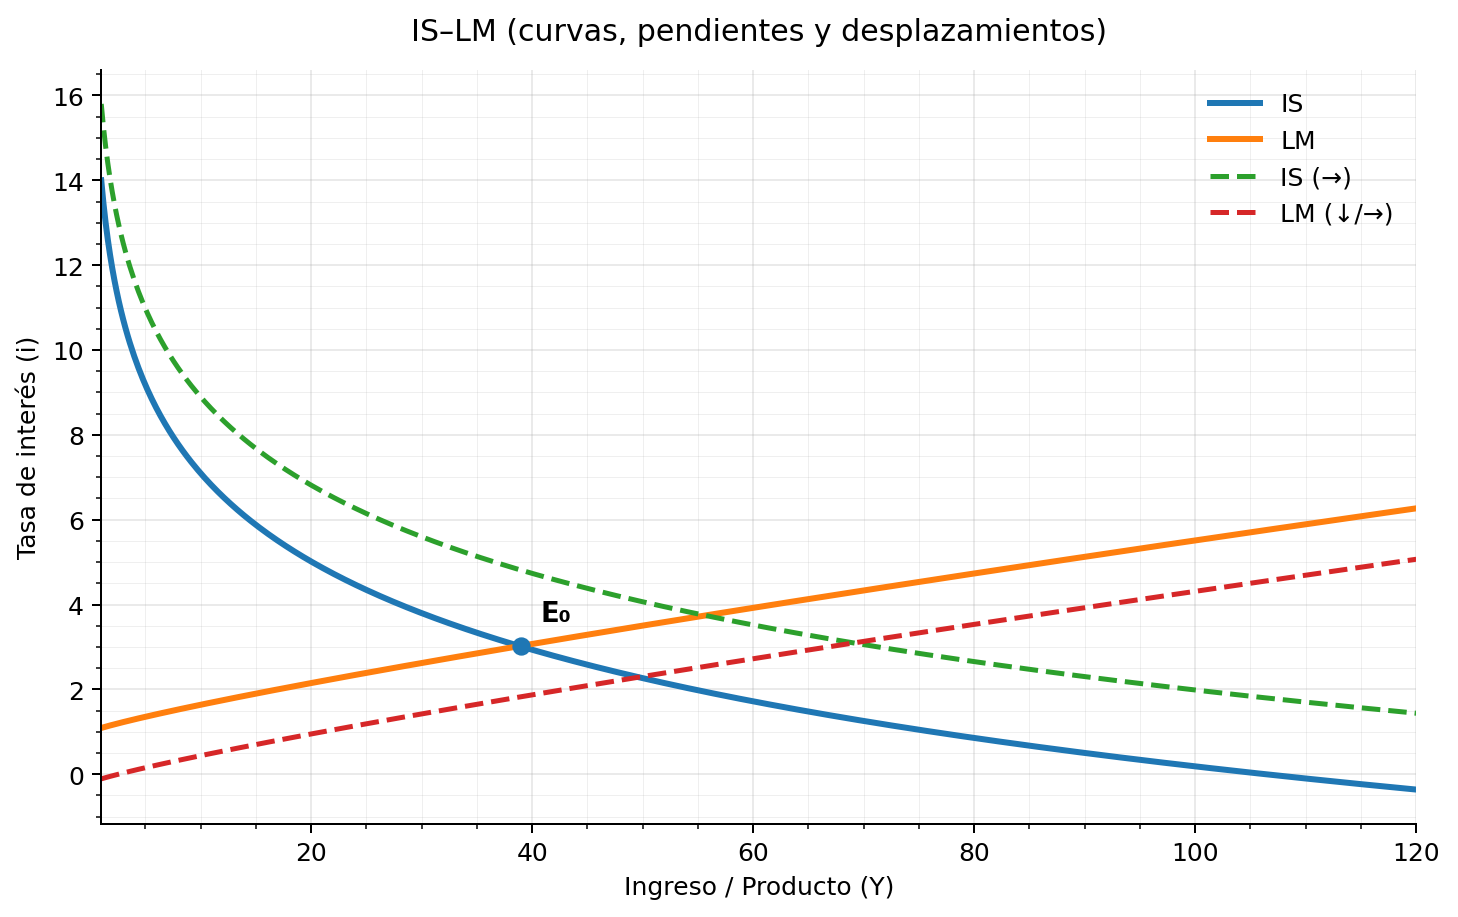

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# IS–LM curvilíneo (minimalista)
# IS: i(Y) = a - b * ln(Y)     (pendiente negativa, convexidad suave)
# LM: i(Y) = c + d * Y^phi     (pendiente positiva, convexidad suave)

# Dominio (Y debe ser > 0 para ln)
Y = np.linspace(1, 120, 600)

# Parámetros base (ajústalos)
a, b = 14.0, 3.0             # IS
c, d, phi = 1.0, 0.09, 0.85  # LM

i_IS = a - b * np.log(Y)
i_LM = c + d * (Y ** phi)

# Desplazamientos 
# IS → (expansión fiscal): sube "a" (más demanda autónoma)
a_shift = a + 1.8
i_IS_shift = a_shift - b * np.log(Y)

# LM ↓/→ (expansión monetaria): baja "c" (más M/P reduce i para cada Y)
c_shift = c - 1.2
i_LM_shift = c_shift + d * (Y ** phi)

# Función para hallar intersección aproximada por búsqueda en malla
def approx_intersection(x, f, g):
    idx = np.argmin(np.abs(f - g))
    return x[idx], f[idx]

Y0, i0 = approx_intersection(Y, i_IS, i_LM)

# Plot
fig, ax = plt.subplots(figsize=(8.2, 5.2), dpi=180)

# Curvas principales (sin fijar colores)
ax.plot(Y, i_IS, linewidth=2.4, label="IS")
ax.plot(Y, i_LM, linewidth=2.4, label="LM")

# Curvas desplazadas (trazo discontinuo)
ax.plot(Y, i_IS_shift, linewidth=2.0, linestyle="--", label="IS (→)")
ax.plot(Y, i_LM_shift, linewidth=2.0, linestyle="--", label="LM (↓/→)")

# Equilibrio inicial
ax.scatter([Y0], [i0], s=40, zorder=5)
ax.annotate("E₀", (Y0, i0), xytext=(8, 10), textcoords="offset points",
            fontsize=11, weight="bold")

ax.set_title("IS–LM (curvas, pendientes y desplazamientos)", pad=12)
ax.set_xlabel("Ingreso / Producto (Y)")
ax.set_ylabel("Tasa de interés (i)")

ax.grid(True, which="major", linewidth=0.6, alpha=0.35)
ax.grid(True, which="minor", linewidth=0.4, alpha=0.2)
ax.minorticks_on()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Límites automáticos con margen
y_min = min(i_IS.min(), i_LM.min(), i_IS_shift.min(), i_LM_shift.min())
y_max = max(i_IS.max(), i_LM.max(), i_IS_shift.max(), i_LM_shift.max())
ax.set_xlim(Y.min(), Y.max())
ax.set_ylim(y_min - 0.8, y_max + 0.8)

# Leyenda
ax.legend(frameon=False, loc="upper right")

plt.tight_layout()
plt.savefig("is_lm_curvas_minimal.png")
plt.show()